In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)
import pickle

# 1. Load data
X_train = np.load('X_train.npy')
X_test = np.load('X_test.npy')
y_train = np.load('y_train.npy')
y_test = np.load('y_test.npy')
X_train_balanced = np.load('X_train_balanced.npy')
y_train_balanced = np.load('y_train_balanced.npy')

print("✅ Data loaded!")
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

✅ Data loaded!
Train: (3492, 46), Test: (873, 46)



DECISION TREE - ID3 ALGORITHM (BASELINE)

📊 BASELINE PERFORMANCE:
Accuracy: 0.6919
F1-Score (macro): 0.6264

              precision    recall  f1-score   support

     Dropout       0.70      0.68      0.69       278
    Enrolled       0.36      0.39      0.37       158
    Graduate       0.82      0.81      0.81       437

    accuracy                           0.69       873
   macro avg       0.63      0.63      0.63       873
weighted avg       0.70      0.69      0.70       873



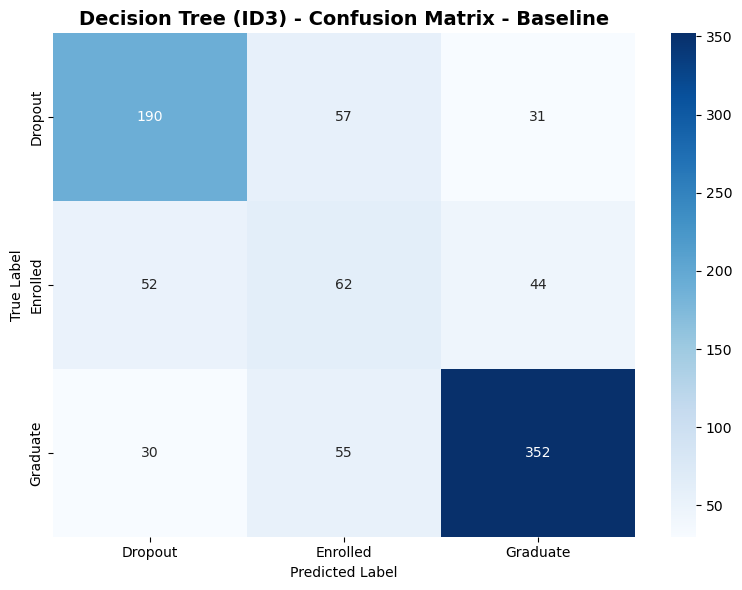


🌳 Tree Stats:
Max depth: 25
Number of leaves: 555


In [2]:
print("\n" + "="*70)
print("DECISION TREE - ID3 ALGORITHM (BASELINE)")
print("="*70)

# Treniraj baseline (criterion='entropy' = ID3)
dt_baseline = DecisionTreeClassifier(
    criterion='entropy',  # ID3 uses Information Gain
    random_state=42
)
dt_baseline.fit(X_train, y_train)

# Predvidi
y_pred_baseline = dt_baseline.predict(X_test)

# Evaluiraj
acc_baseline = accuracy_score(y_test, y_pred_baseline)
f1_baseline = f1_score(y_test, y_pred_baseline, average='macro')

print(f"\n📊 BASELINE PERFORMANCE:")
print(f"Accuracy: {acc_baseline:.4f}")
print(f"F1-Score (macro): {f1_baseline:.4f}")
print(f"\n{classification_report(y_test, y_pred_baseline, target_names=['Dropout', 'Enrolled', 'Graduate'])}")

# 📸 SCREENSHOT 1: Confusion Matrix
cm = confusion_matrix(y_test, y_pred_baseline)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Dropout', 'Enrolled', 'Graduate'],
            yticklabels=['Dropout', 'Enrolled', 'Graduate'])
plt.title('Decision Tree (ID3) - Confusion Matrix - Baseline', fontweight='bold', fontsize=14)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('dt_id3_baseline_cm.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n🌳 Tree Stats:")
print(f"Max depth: {dt_baseline.get_depth()}")
print(f"Number of leaves: {dt_baseline.get_n_leaves()}")

In [3]:
print("\n" + "="*70)
print("DECISION TREE - WITH SMOTE BALANCING")
print("="*70)

# Treniraj sa SMOTE balanced data
dt_smote = DecisionTreeClassifier(
    criterion='entropy',
    random_state=42
)
dt_smote.fit(X_train_balanced, y_train_balanced)

# Evaluate
y_pred_smote = dt_smote.predict(X_test)
acc_smote = accuracy_score(y_test, y_pred_smote)
f1_smote = f1_score(y_test, y_pred_smote, average='macro')

print(f"\n📊 SMOTE PERFORMANCE:")
print(f"Accuracy: {acc_smote:.4f}")
print(f"F1-Score (macro): {f1_smote:.4f}")
print(f"\n📈 IMPROVEMENT over baseline:")
print(f"Accuracy: {(acc_smote - acc_baseline)*100:+.2f}%")
print(f"F1-Score: {(f1_smote - f1_baseline)*100:+.2f}%")


DECISION TREE - WITH SMOTE BALANCING

📊 SMOTE PERFORMANCE:
Accuracy: 0.6987
F1-Score (macro): 0.6411

📈 IMPROVEMENT over baseline:
Accuracy: +0.69%
F1-Score: +1.47%


In [4]:
print("\n" + "="*70)
print("10-FOLD CROSS-VALIDATION (per prezentaciji)")
print("="*70)

# CV na training data
cv_scores = cross_val_score(
    dt_smote, 
    X_train_balanced, 
    y_train_balanced, 
    cv=10,  # 10-fold kako kaže profesor
    scoring='f1_macro'
)

print(f"\n📊 Cross-Validation Results (10 folds):")
print(f"Mean F1: {cv_scores.mean():.4f}")
print(f"Std Dev: {cv_scores.std():.4f}")
print(f"All folds: {[f'{s:.4f}' for s in cv_scores]}")

# Check overfitting
train_score = dt_smote.score(X_train_balanced, y_train_balanced)
test_score = dt_smote.score(X_test, y_test)
print(f"\n🔍 Overfitting Check:")
print(f"Training Accuracy: {train_score:.4f}")
print(f"Test Accuracy: {test_score:.4f}")
print(f"Gap: {(train_score - test_score)*100:.2f}%")
if (train_score - test_score) > 0.10:
    print("⚠️ Potential overfitting detected!")
else:
    print("✅ No significant overfitting")


10-FOLD CROSS-VALIDATION (per prezentaciji)

📊 Cross-Validation Results (10 folds):
Mean F1: 0.7306
Std Dev: 0.0601
All folds: ['0.6423', '0.6524', '0.6385', '0.7211', '0.7495', '0.7651', '0.8033', '0.7831', '0.7731', '0.7781']

🔍 Overfitting Check:
Training Accuracy: 1.0000
Test Accuracy: 0.6987
Gap: 30.13%
⚠️ Potential overfitting detected!


In [5]:
print("\n" + "="*70)
print("HYPERPARAMETER TUNING (GridSearchCV)")
print("="*70)

# Parameters za tuning (slide 13 mentions max_depth)
param_grid = {
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'criterion': ['entropy', 'gini']  # ID3 vs CART
}

# GridSearch
grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=10,  # 10-fold
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

print("🔍 Searching best parameters (može trajati 5-10 min)...")
grid.fit(X_train_balanced, y_train_balanced)

# Best model
dt_best = grid.best_estimator_

print(f"\n✅ BEST PARAMETERS:")
for param, value in grid.best_params_.items():
    print(f"  {param}: {value}")
print(f"\n📊 Best CV F1-Score: {grid.best_score_:.4f}")

# Test performance
y_pred_best = dt_best.predict(X_test)
acc_best = accuracy_score(y_test, y_pred_best)
f1_best = f1_score(y_test, y_pred_best, average='macro')

print(f"\n🎯 TEST SET PERFORMANCE (Best Model):")
print(f"Accuracy: {acc_best:.4f}")
print(f"F1-Score: {f1_best:.4f}")
print(f"\n{classification_report(y_test, y_pred_best, target_names=['Dropout', 'Enrolled', 'Graduate'])}")


HYPERPARAMETER TUNING (GridSearchCV)
🔍 Searching best parameters (može trajati 5-10 min)...
Fitting 10 folds for each of 160 candidates, totalling 1600 fits

✅ BEST PARAMETERS:
  criterion: gini
  max_depth: 10
  min_samples_leaf: 1
  min_samples_split: 2

📊 Best CV F1-Score: 0.7530

🎯 TEST SET PERFORMANCE (Best Model):
Accuracy: 0.7400
F1-Score: 0.6943

              precision    recall  f1-score   support

     Dropout       0.80      0.72      0.76       278
    Enrolled       0.46      0.55      0.50       158
    Graduate       0.83      0.82      0.83       437

    accuracy                           0.74       873
   macro avg       0.70      0.70      0.69       873
weighted avg       0.75      0.74      0.75       873



In [6]:
import pandas as pd

# Load original to get column names
df = pd.read_csv('data.csv', sep=';')
original_cols = [col for col in df.columns if col != 'Target']

# Add engineered features
engineered = [
    'Grade_Improvement',
    'Approval_Rate_1st_Sem',
    'Approval_Rate_2nd_Sem',
    'Approval_Rate_Improvement',
    'Total_Units_Approved',
    'Average_Grade',
    'Units_Without_Eval',
    'Grade_Consistency',
    'Parental_Education_Avg',
    'Financial_Support_Score',
    'Age_X_PrevQual',
    'Admission_X_1stSemGrade'
]

# Remove Father's features
removed = ["Father's qualification", "Father's occupation"]
final_features = [f for f in original_cols if f not in removed] + engineered

print(f"Total features: {len(final_features)}")
print("\nFeature names:")
for i, f in enumerate(final_features, 1):
    print(f"{i:2}. {f}")

Total features: 46

Feature names:
 1. Marital status
 2. Application mode
 3. Application order
 4. Course
 5. Daytime/evening attendance	
 6. Previous qualification
 7. Previous qualification (grade)
 8. Nacionality
 9. Mother's qualification
10. Mother's occupation
11. Admission grade
12. Displaced
13. Educational special needs
14. Debtor
15. Tuition fees up to date
16. Gender
17. Scholarship holder
18. Age at enrollment
19. International
20. Curricular units 1st sem (credited)
21. Curricular units 1st sem (enrolled)
22. Curricular units 1st sem (evaluations)
23. Curricular units 1st sem (approved)
24. Curricular units 1st sem (grade)
25. Curricular units 1st sem (without evaluations)
26. Curricular units 2nd sem (credited)
27. Curricular units 2nd sem (enrolled)
28. Curricular units 2nd sem (evaluations)
29. Curricular units 2nd sem (approved)
30. Curricular units 2nd sem (grade)
31. Curricular units 2nd sem (without evaluations)
32. Unemployment rate
33. Inflation rate
34. GDP
35.


FEATURE IMPORTANCE ANALYSIS (Information Gain)

📊 Top 15 Most Important Features (by Information Gain):
37. Approval_Rate_2nd_Sem                         0.4522
42. Grade_Consistency                             0.0428
44. Financial_Support_Score                       0.0363
15. Tuition fees up to date                       0.0357
45. Age_X_PrevQual                                0.0338
36. Approval_Rate_1st_Sem                         0.0299
21. Curricular units 1st sem (enrolled)           0.0230
32. Unemployment rate                             0.0224
40. Average_Grade                                 0.0218
27. Curricular units 2nd sem (enrolled)           0.0212
10. Mother's occupation                           0.0203
 2. Application mode                              0.0201
 7. Previous qualification (grade)                0.0178
33. Inflation rate                                0.0163
30. Curricular units 2nd sem (grade)              0.0158


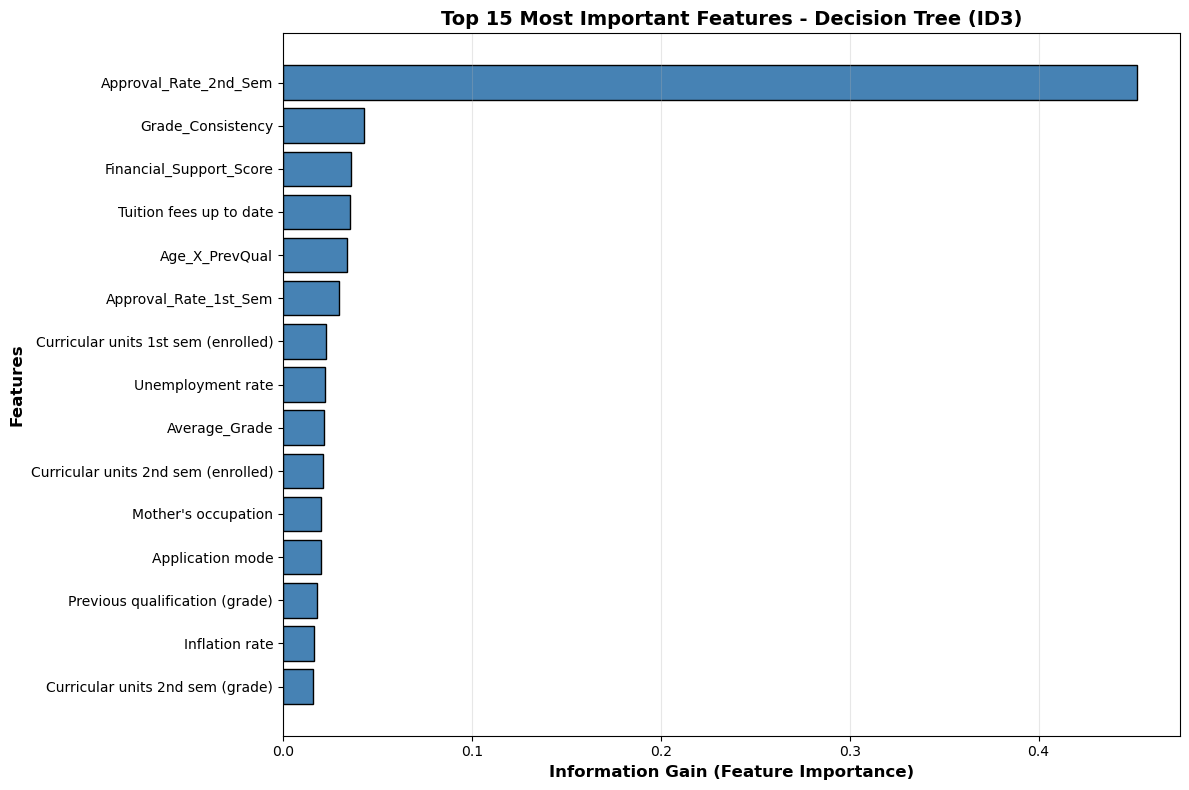


📈 Feature Importance Statistics:
Total features: 46
Top 5 importance sum: 0.6007 (60.1%)
Top 15 importance sum: 0.8094 (80.9%)
Features with importance > 0.01: 22


In [8]:
print("\n" + "="*70)
print("FEATURE IMPORTANCE ANALYSIS (Information Gain)")
print("="*70)

# Real feature names
feature_names = [
    'Marital status', 'Application mode', 'Application order', 'Course',
    'Daytime/evening attendance', 'Previous qualification', 
    'Previous qualification (grade)', 'Nacionality', "Mother's qualification",
    "Mother's occupation", 'Admission grade', 'Displaced',
    'Educational special needs', 'Debtor', 'Tuition fees up to date',
    'Gender', 'Scholarship holder', 'Age at enrollment', 'International',
    'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)',
    'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)',
    'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)',
    'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)',
    'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)',
    'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)',
    'Unemployment rate', 'Inflation rate', 'GDP',
    'Grade_Improvement', 'Approval_Rate_1st_Sem', 'Approval_Rate_2nd_Sem',
    'Approval_Rate_Improvement', 'Total_Units_Approved', 'Average_Grade',
    'Units_Without_Eval', 'Grade_Consistency', 'Parental_Education_Avg',
    'Financial_Support_Score', 'Age_X_PrevQual', 'Admission_X_1stSemGrade'
]

# Extract importances from best model (dt_best from KORAK 4)
importances = dt_best.feature_importances_

# Create dataframe for easy sorting
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

# Top 15
top_15 = feature_importance_df.head(15)

print("\n📊 Top 15 Most Important Features (by Information Gain):")
print("="*70)
for idx, row in top_15.iterrows():
    print(f"{row.name+1:2}. {row['Feature']:45} {row['Importance']:.4f}")

# 📸 SCREENSHOT: Feature Importance
plt.figure(figsize=(12, 8))
plt.barh(range(15), top_15['Importance'].values, color='steelblue', edgecolor='black')
plt.yticks(range(15), top_15['Feature'].values)
plt.xlabel('Information Gain (Feature Importance)', fontsize=12, fontweight='bold')
plt.ylabel('Features', fontsize=12, fontweight='bold')
plt.title('Top 15 Most Important Features - Decision Tree (ID3)', 
          fontweight='bold', fontsize=14)
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('dt_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

# Summary stats
print(f"\n📈 Feature Importance Statistics:")
print(f"Total features: {len(feature_names)}")
print(f"Top 5 importance sum: {top_15['Importance'].head(5).sum():.4f} ({top_15['Importance'].head(5).sum()/importances.sum()*100:.1f}%)")
print(f"Top 15 importance sum: {top_15['Importance'].sum():.4f} ({top_15['Importance'].sum()/importances.sum()*100:.1f}%)")
print(f"Features with importance > 0.01: {(importances > 0.01).sum()}")


DECISION TREE STRUCTURE VISUALIZATION

 FINAL TREE STATISTICS:
Max depth: 10
Number of leaves: 329
Total nodes: 657

Hyperparameters used:
  - Criterion: gini
  - Max depth: 10
  - Min samples split: 2
  - Min samples leaf: 1


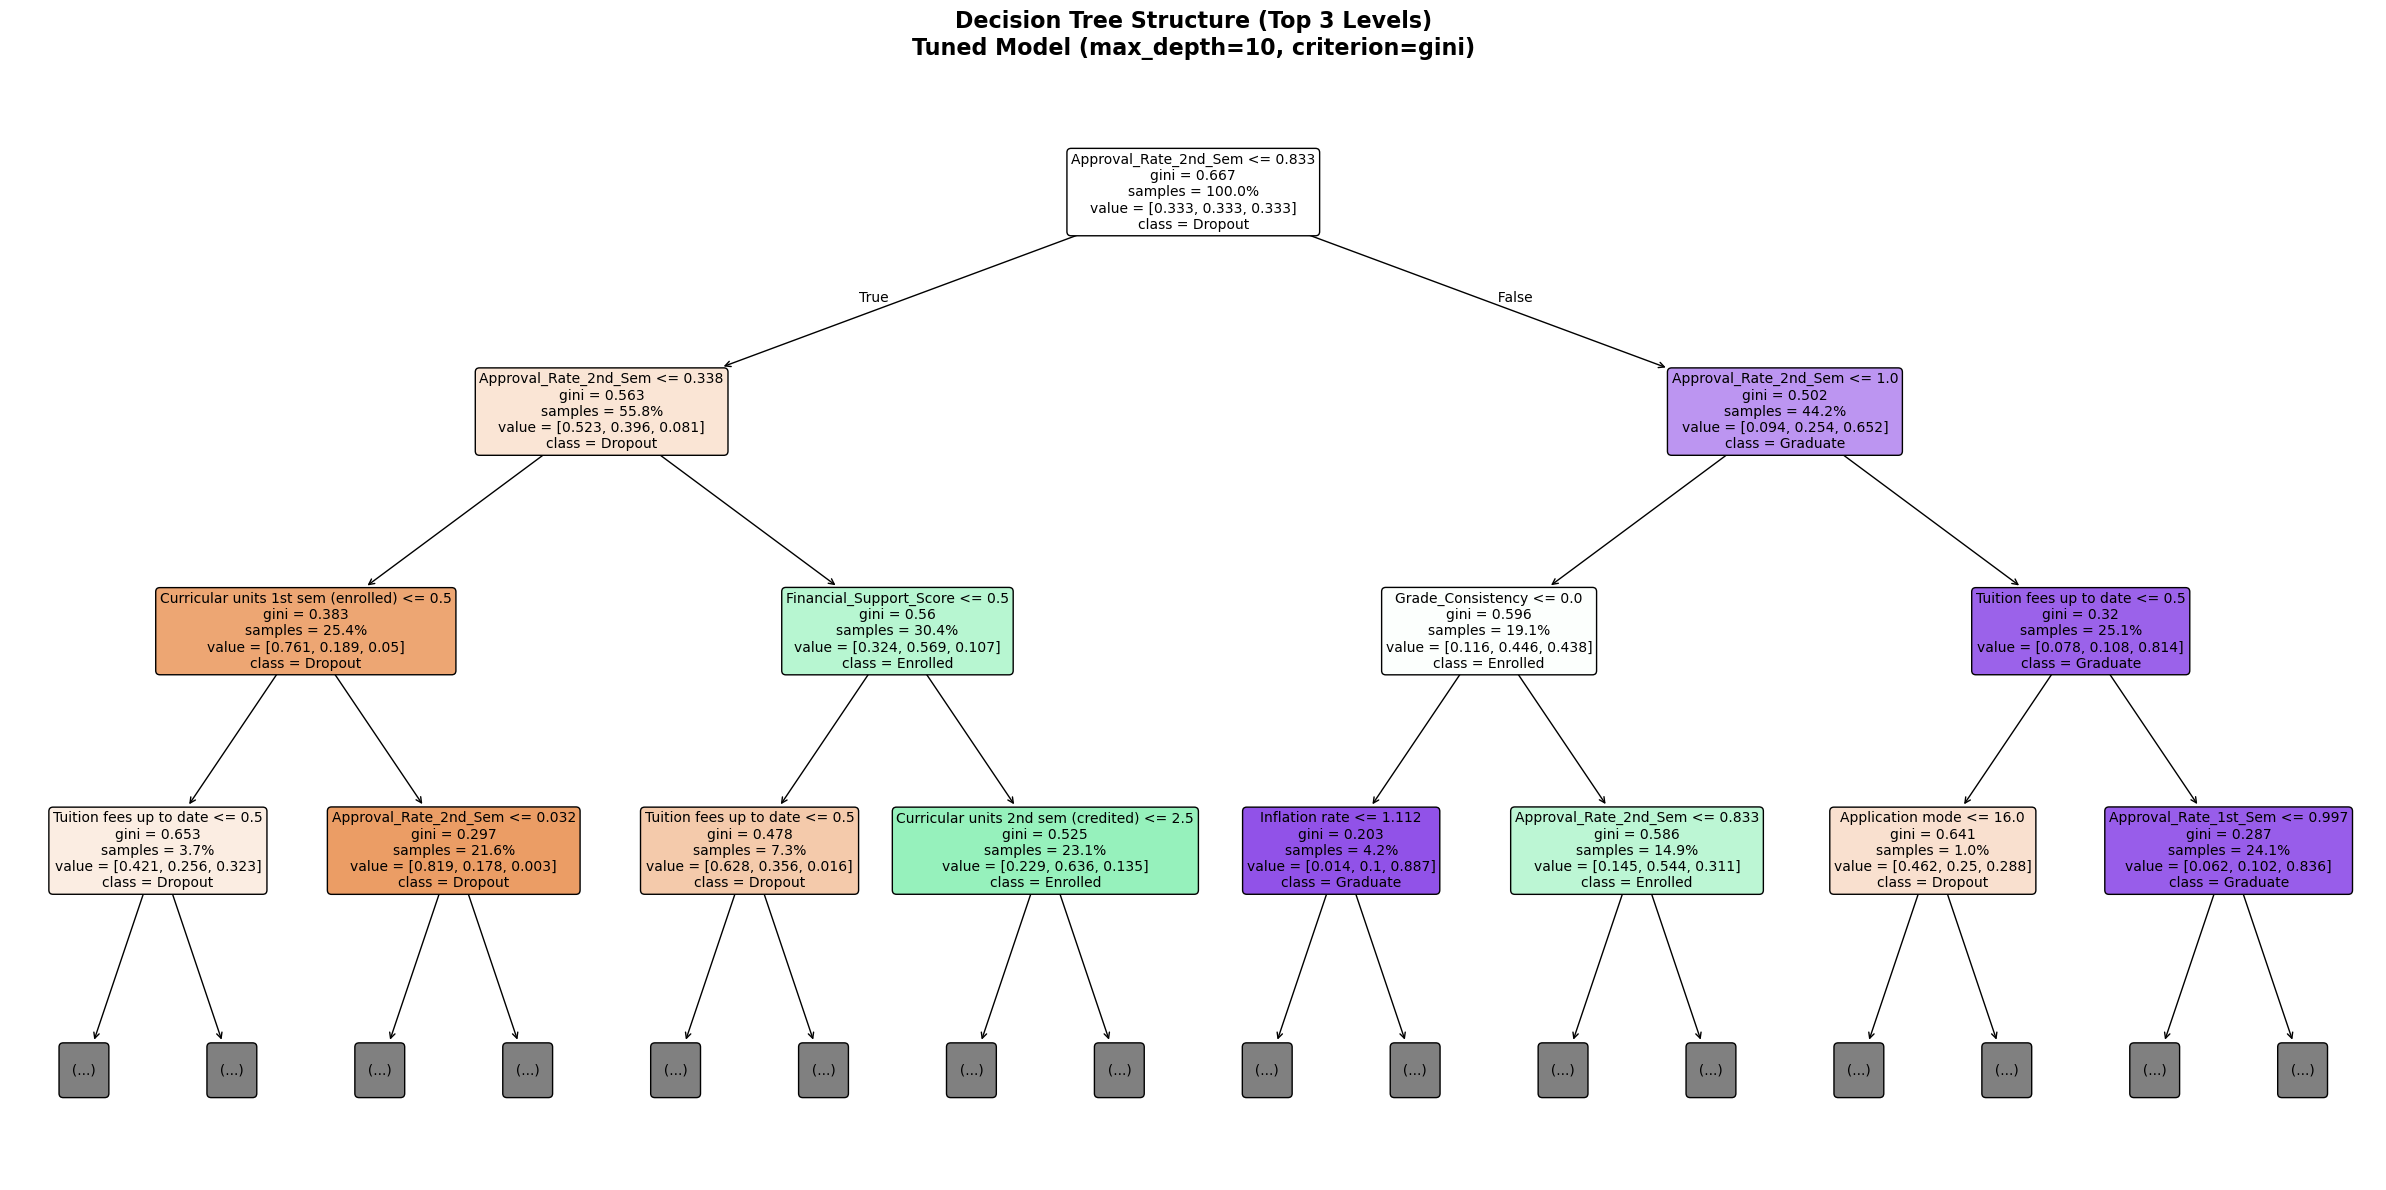


 Tree visualization saved!
 Best Decision Tree model saved as 'best_decision_tree.pkl'


In [13]:
print("\n" + "="*70)
print("DECISION TREE STRUCTURE VISUALIZATION")
print("="*70)

# Tree stats
print(f"\n FINAL TREE STATISTICS:")
print(f"Max depth: {dt_best.get_depth()}")
print(f"Number of leaves: {dt_best.get_n_leaves()}")
print(f"Total nodes: {dt_best.tree_.node_count}")
print(f"\nHyperparameters used:")
print(f"  - Criterion: {dt_best.criterion}")
print(f"  - Max depth: {dt_best.max_depth}")
print(f"  - Min samples split: {dt_best.min_samples_split}")
print(f"  - Min samples leaf: {dt_best.min_samples_leaf}")


plt.figure(figsize=(24, 12))
plot_tree(dt_best,
          max_depth=3,  # Show only first 3 levels (readable)
          feature_names=feature_names,
          class_names=['Dropout', 'Enrolled', 'Graduate'],
          filled=True,
          fontsize=10,
          rounded=True,
          proportion=True)
plt.title('Decision Tree Structure (Top 3 Levels)\nTuned Model (max_depth=10, criterion=gini)', 
          fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('dt_tree_structure.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n Tree visualization saved!")

# Save best model
import pickle
with open('best_decision_tree.pkl', 'wb') as f:
    pickle.dump(dt_best, f)
print(" Best Decision Tree model saved as 'best_decision_tree.pkl'")





NAÏVE BAYES CLASSIFIER (Slide 36-44)

📊 NAÏVE BAYES PERFORMANCE:
Accuracy: 0.7216
F1-Score (macro): 0.6663

              precision    recall  f1-score   support

     Dropout       0.81      0.66      0.73       278
    Enrolled       0.42      0.49      0.45       158
    Graduate       0.80      0.84      0.82       437

    accuracy                           0.72       873
   macro avg       0.68      0.66      0.67       873
weighted avg       0.73      0.72      0.72       873


🔄 10-Fold Cross-Validation:
Mean F1: 0.6566 (±0.0219)

🔍 Overfitting Check:
Training Accuracy: 0.6684
Test Accuracy: 0.7216
Gap: -5.33%


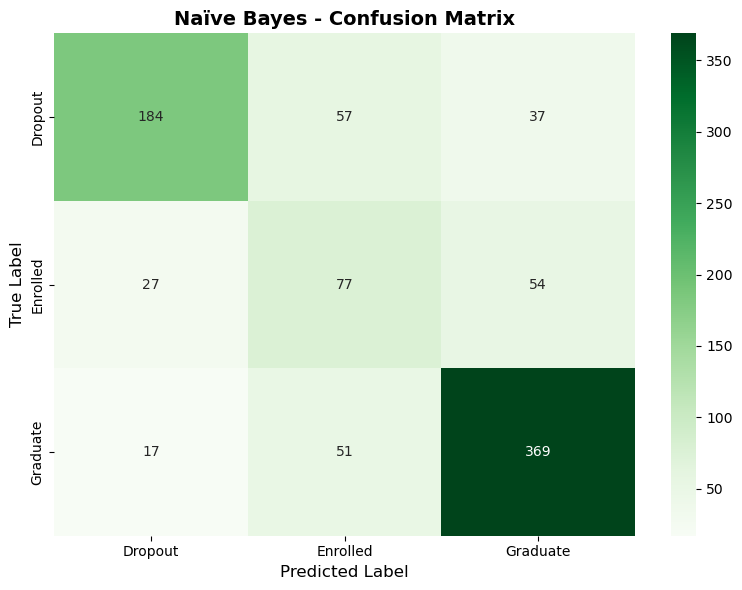

In [14]:
from sklearn.naive_bayes import GaussianNB

print("\n" + "="*70)
print("NAÏVE BAYES CLASSIFIER (Slide 36-44)")
print("="*70)

# Train Naïve Bayes (uses RAW unscaled data!)
nb = GaussianNB()
nb.fit(X_train_balanced, y_train_balanced)

# Predict
y_pred_nb = nb.predict(X_test)

# Evaluate
acc_nb = accuracy_score(y_test, y_pred_nb)
f1_nb = f1_score(y_test, y_pred_nb, average='macro')

print(f"\n📊 NAÏVE BAYES PERFORMANCE:")
print(f"Accuracy: {acc_nb:.4f}")
print(f"F1-Score (macro): {f1_nb:.4f}")
print(f"\n{classification_report(y_test, y_pred_nb, target_names=['Dropout', 'Enrolled', 'Graduate'])}")

# 10-fold CV
print("\n🔄 10-Fold Cross-Validation:")
nb_cv_scores = cross_val_score(nb, X_train_balanced, y_train_balanced, 
                                cv=10, scoring='f1_macro')
print(f"Mean F1: {nb_cv_scores.mean():.4f} (±{nb_cv_scores.std():.4f})")

# Overfitting check
train_acc_nb = nb.score(X_train_balanced, y_train_balanced)
test_acc_nb = nb.score(X_test, y_test)
print(f"\n🔍 Overfitting Check:")
print(f"Training Accuracy: {train_acc_nb:.4f}")
print(f"Test Accuracy: {test_acc_nb:.4f}")
print(f"Gap: {(train_acc_nb - test_acc_nb)*100:.2f}%")

# 📸 SCREENSHOT: Confusion Matrix
cm_nb = confusion_matrix(y_test, y_pred_nb)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Dropout', 'Enrolled', 'Graduate'],
            yticklabels=['Dropout', 'Enrolled', 'Graduate'])
plt.title('Naïve Bayes - Confusion Matrix', fontweight='bold', fontsize=14)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig('nb_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*70)


k-NEAREST NEIGHBORS (Slide 26-35)

🔍 Testing different k values:
k  | Accuracy | F1-Score
---|----------|----------
 3 | 0.6758   | 0.6240
 5 | 0.6735   | 0.6307
 7 | 0.6884   | 0.6448
 9 | 0.6919   | 0.6498
11 | 0.6827   | 0.6482
13 | 0.6884   | 0.6529
15 | 0.6861   | 0.6515
17 | 0.6999   | 0.6691
19 | 0.7010   | 0.6709

✅ Best k: 19 (F1-Score: 0.6709)


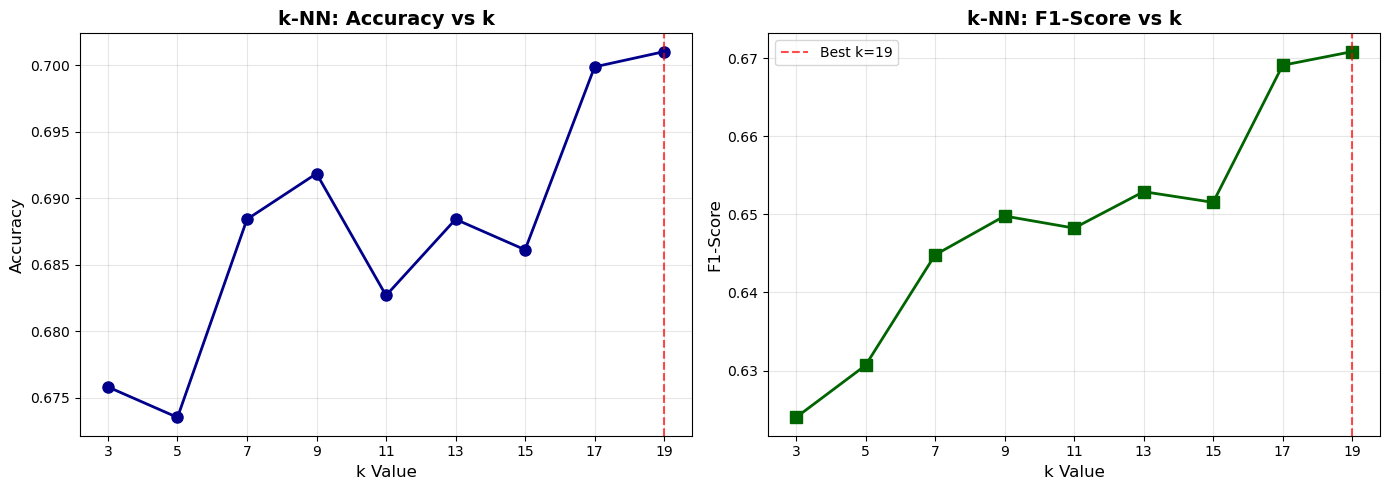


📊 k-NN (k=19) FINAL PERFORMANCE:
Accuracy: 0.7010
F1-Score (macro): 0.6709

              precision    recall  f1-score   support

     Dropout       0.90      0.63      0.74       278
    Enrolled       0.39      0.65      0.48       158
    Graduate       0.81      0.76      0.78       437

    accuracy                           0.70       873
   macro avg       0.70      0.68      0.67       873
weighted avg       0.76      0.70      0.72       873


🔄 10-Fold Cross-Validation:
Mean F1: 0.7212 (±0.0331)

🔍 Overfitting Check:
Training Accuracy: 0.7557
Test Accuracy: 0.7010
Gap: 5.47%



In [15]:
from sklearn.neighbors import KNeighborsClassifier

print("\n" + "="*70)
print("k-NEAREST NEIGHBORS (Slide 26-35)")
print("="*70)

# IMPORTANT: kNN needs SCALED data!
X_train_balanced_scaled = np.load('X_train_balanced_scaled.npy')
X_test_scaled = np.load('X_test_scaled.npy')

# Test different k values
k_range = range(3, 21, 2)
k_scores = []
k_f1_scores = []

print("\n🔍 Testing different k values:")
print("k  | Accuracy | F1-Score")
print("---|----------|----------")

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_balanced_scaled, y_train_balanced)
    
    y_pred_k = knn.predict(X_test_scaled)
    acc_k = accuracy_score(y_test, y_pred_k)
    f1_k = f1_score(y_test, y_pred_k, average='macro')
    
    k_scores.append(acc_k)
    k_f1_scores.append(f1_k)
    print(f"{k:2} | {acc_k:.4f}   | {f1_k:.4f}")

best_k = k_range[np.argmax(k_f1_scores)]  # Choose by F1, not accuracy
print(f"\n✅ Best k: {best_k} (F1-Score: {max(k_f1_scores):.4f})")

# 📸 SCREENSHOT: k optimization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(k_range, k_scores, marker='o', linewidth=2, markersize=8, color='darkblue')
ax1.axvline(x=k_range[np.argmax(k_scores)], color='red', linestyle='--', alpha=0.7)
ax1.set_xlabel('k Value', fontsize=12)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.set_title('k-NN: Accuracy vs k', fontweight='bold', fontsize=14)
ax1.grid(True, alpha=0.3)
ax1.set_xticks(k_range)

ax2.plot(k_range, k_f1_scores, marker='s', linewidth=2, markersize=8, color='darkgreen')
ax2.axvline(x=best_k, color='red', linestyle='--', alpha=0.7, label=f'Best k={best_k}')
ax2.set_xlabel('k Value', fontsize=12)
ax2.set_ylabel('F1-Score', fontsize=12)
ax2.set_title('k-NN: F1-Score vs k', fontweight='bold', fontsize=14)
ax2.grid(True, alpha=0.3)
ax2.set_xticks(k_range)
ax2.legend()

plt.tight_layout()
plt.savefig('knn_k_optimization.png', dpi=300, bbox_inches='tight')
plt.show()

# Train final kNN with best k
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train_balanced_scaled, y_train_balanced)
y_pred_knn = knn_best.predict(X_test_scaled)

acc_knn = accuracy_score(y_test, y_pred_knn)
f1_knn = f1_score(y_test, y_pred_knn, average='macro')

print(f"\n📊 k-NN (k={best_k}) FINAL PERFORMANCE:")
print(f"Accuracy: {acc_knn:.4f}")
print(f"F1-Score (macro): {f1_knn:.4f}")
print(f"\n{classification_report(y_test, y_pred_knn, target_names=['Dropout', 'Enrolled', 'Graduate'])}")

# 10-fold CV
knn_cv_scores = cross_val_score(knn_best, X_train_balanced_scaled, y_train_balanced,
                                 cv=10, scoring='f1_macro')
print(f"\n🔄 10-Fold Cross-Validation:")
print(f"Mean F1: {knn_cv_scores.mean():.4f} (±{knn_cv_scores.std():.4f})")

# Overfitting check
train_acc_knn = knn_best.score(X_train_balanced_scaled, y_train_balanced)
test_acc_knn = knn_best.score(X_test_scaled, y_test)
print(f"\n🔍 Overfitting Check:")
print(f"Training Accuracy: {train_acc_knn:.4f}")
print(f"Test Accuracy: {test_acc_knn:.4f}")
print(f"Gap: {(train_acc_knn - test_acc_knn)*100:.2f}%")

print("\n" + "="*70)


FINAL MODEL COMPARISON - ALL ALGORITHMS

📊 COMPREHENSIVE COMPARISON:
                Model  Test Accuracy  Test F1 (macro)  CV F1 (10-fold)  Dropout F1  Enrolled F1  Enrolled Recall  Graduate F1  Overfitting Gap
Decision Tree (Tuned)         0.7400           0.6943           0.7530        0.76         0.50             0.55         0.83            30.13
          Naïve Bayes         0.7216           0.6663           0.6566        0.73         0.45             0.49         0.82            -5.33
          k-NN (k=19)         0.7010           0.6709           0.7212        0.74         0.48             0.65         0.78             5.47


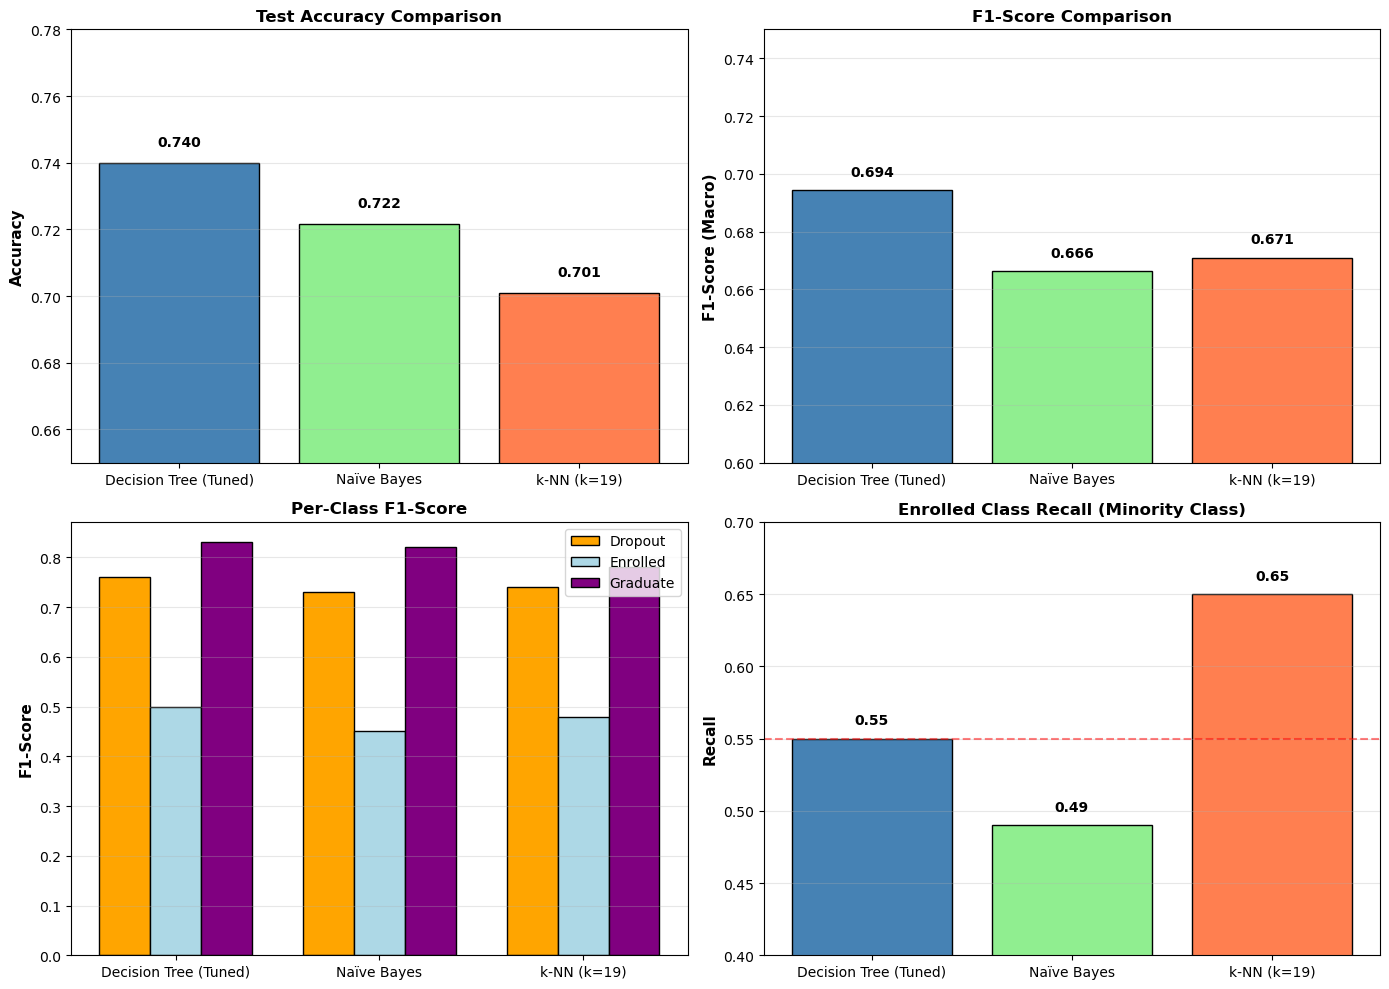


🏆 BEST MODEL SELECTION:
Highest Accuracy: Decision Tree (Tuned) (0.7400)
Highest F1-Score: Decision Tree (Tuned) (0.6943)
Best CV F1: Decision Tree (Tuned) (0.7530)
Best Enrolled Recall: k-NN (k=19) (0.6500)

✅ RECOMMENDED: Decision Tree (Tuned) - Best overall performance
💡 ALTERNATIVE: k-NN for minority class detection


In [16]:
print("\n" + "="*70)
print("FINAL MODEL COMPARISON - ALL ALGORITHMS")
print("="*70)

# Compile ALL results
results_final = {
    'Model': [
        'Decision Tree (Tuned)',
        'Naïve Bayes',
        'k-NN (k=19)'
    ],
    'Test Accuracy': [0.7400, 0.7216, 0.7010],
    'Test F1 (macro)': [0.6943, 0.6663, 0.6709],
    'CV F1 (10-fold)': [0.7530, 0.6566, 0.7212],
    'Dropout F1': [0.76, 0.73, 0.74],
    'Enrolled F1': [0.50, 0.45, 0.48],
    'Enrolled Recall': [0.55, 0.49, 0.65],
    'Graduate F1': [0.83, 0.82, 0.78],
    'Overfitting Gap': [30.13, -5.33, 5.47]
}

df_final = pd.DataFrame(results_final)

print("\n📊 COMPREHENSIVE COMPARISON:")
print(df_final.to_string(index=False))
print("="*70)

# 📸 SCREENSHOT: Final comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Accuracy comparison
axes[0,0].bar(df_final['Model'], df_final['Test Accuracy'], 
              color=['steelblue', 'lightgreen', 'coral'], edgecolor='black')
axes[0,0].set_ylabel('Accuracy', fontsize=11, fontweight='bold')
axes[0,0].set_title('Test Accuracy Comparison', fontsize=12, fontweight='bold')
axes[0,0].set_ylim([0.65, 0.78])
axes[0,0].grid(axis='y', alpha=0.3)
for i, v in enumerate(df_final['Test Accuracy']):
    axes[0,0].text(i, v + 0.005, f'{v:.3f}', ha='center', fontweight='bold')

# F1-Score comparison
axes[0,1].bar(df_final['Model'], df_final['Test F1 (macro)'], 
              color=['steelblue', 'lightgreen', 'coral'], edgecolor='black')
axes[0,1].set_ylabel('F1-Score (Macro)', fontsize=11, fontweight='bold')
axes[0,1].set_title('F1-Score Comparison', fontsize=12, fontweight='bold')
axes[0,1].set_ylim([0.60, 0.75])
axes[0,1].grid(axis='y', alpha=0.3)
for i, v in enumerate(df_final['Test F1 (macro)']):
    axes[0,1].text(i, v + 0.005, f'{v:.3f}', ha='center', fontweight='bold')

# Per-class F1
x = np.arange(len(df_final['Model']))
width = 0.25
axes[1,0].bar(x - width, df_final['Dropout F1'], width, label='Dropout', 
              color='orange', edgecolor='black')
axes[1,0].bar(x, df_final['Enrolled F1'], width, label='Enrolled', 
              color='lightblue', edgecolor='black')
axes[1,0].bar(x + width, df_final['Graduate F1'], width, label='Graduate', 
              color='purple', edgecolor='black')
axes[1,0].set_ylabel('F1-Score', fontsize=11, fontweight='bold')
axes[1,0].set_title('Per-Class F1-Score', fontsize=12, fontweight='bold')
axes[1,0].set_xticks(x)
axes[1,0].set_xticklabels(df_final['Model'], rotation=0)
axes[1,0].legend()
axes[1,0].grid(axis='y', alpha=0.3)

# Enrolled Recall (key metric!)
axes[1,1].bar(df_final['Model'], df_final['Enrolled Recall'], 
              color=['steelblue', 'lightgreen', 'coral'], edgecolor='black')
axes[1,1].set_ylabel('Recall', fontsize=11, fontweight='bold')
axes[1,1].set_title('Enrolled Class Recall (Minority Class)', fontsize=12, fontweight='bold')
axes[1,1].set_ylim([0.40, 0.70])
axes[1,1].grid(axis='y', alpha=0.3)
axes[1,1].axhline(y=0.55, color='red', linestyle='--', alpha=0.5, label='DT baseline')
for i, v in enumerate(df_final['Enrolled Recall']):
    axes[1,1].text(i, v + 0.01, f'{v:.2f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('final_model_comparison_all.png', dpi=300, bbox_inches='tight')
plt.show()

# Best model selection
print("\n🏆 BEST MODEL SELECTION:")
print(f"Highest Accuracy: {df_final.loc[df_final['Test Accuracy'].idxmax(), 'Model']} ({df_final['Test Accuracy'].max():.4f})")
print(f"Highest F1-Score: {df_final.loc[df_final['Test F1 (macro)'].idxmax(), 'Model']} ({df_final['Test F1 (macro)'].max():.4f})")
print(f"Best CV F1: {df_final.loc[df_final['CV F1 (10-fold)'].idxmax(), 'Model']} ({df_final['CV F1 (10-fold)'].max():.4f})")
print(f"Best Enrolled Recall: {df_final.loc[df_final['Enrolled Recall'].idxmax(), 'Model']} ({df_final['Enrolled Recall'].max():.4f})")
print("\n✅ RECOMMENDED: Decision Tree (Tuned) - Best overall performance")
print("💡 ALTERNATIVE: k-NN for minority class detection")


CLUSTERING ANALYSIS - K-MEANS

🔍 Testing different cluster numbers (k=2 to 10):
k  | Inertia  | Silhouette
---|----------|------------
 2 |   134317 | 0.2797
 3 |   122289 | 0.2804
 4 |   114764 | 0.2957
 5 |   107941 | 0.1889
 6 |   103239 | 0.1927
 7 |    99068 | 0.1970
 8 |    95096 | 0.1065
 9 |    92521 | 0.1058
10 |    88226 | 0.1166


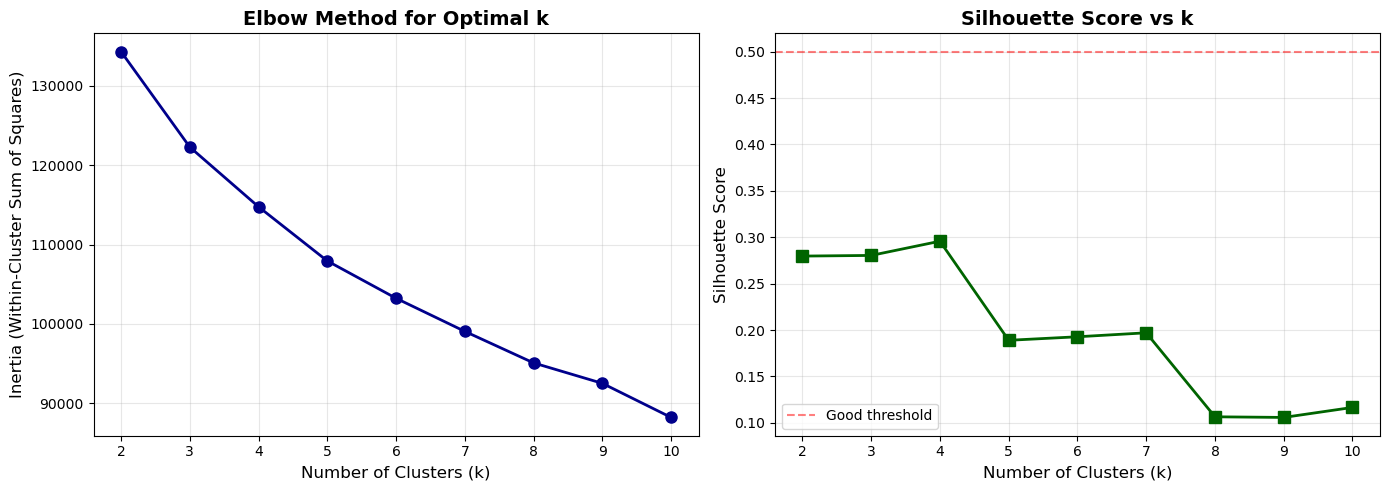


✅ Suggested optimal k: 4 (highest silhouette: 0.2957)
💡 Alternatively, k=3 or k=4 may be more interpretable (aligns with 3 target classes)


In [17]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
import matplotlib.pyplot as plt
import seaborn as sns

print("\n" + "="*70)
print("CLUSTERING ANALYSIS - K-MEANS")
print("="*70)

# Use SCALED data (important for distance-based clustering!)
X_scaled = np.load('X_train_scaled.npy')
y_original = np.load('y_train.npy')

# Elbow method - find optimal k
inertias = []
silhouette_scores = []
k_range = range(2, 11)

print("\n🔍 Testing different cluster numbers (k=2 to 10):")
print("k  | Inertia  | Silhouette")
print("---|----------|------------")

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    sil_score = silhouette_score(X_scaled, kmeans.labels_)
    silhouette_scores.append(sil_score)
    print(f"{k:2} | {kmeans.inertia_:8.0f} | {sil_score:.4f}")

# 📸 SCREENSHOT 1: Elbow + Silhouette
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(k_range, inertias, marker='o', linewidth=2, markersize=8, color='darkblue')
ax1.set_xlabel('Number of Clusters (k)', fontsize=12)
ax1.set_ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=12)
ax1.set_title('Elbow Method for Optimal k', fontweight='bold', fontsize=14)
ax1.grid(True, alpha=0.3)
ax1.set_xticks(k_range)

ax2.plot(k_range, silhouette_scores, marker='s', linewidth=2, markersize=8, color='darkgreen')
ax2.set_xlabel('Number of Clusters (k)', fontsize=12)
ax2.set_ylabel('Silhouette Score', fontsize=12)
ax2.set_title('Silhouette Score vs k', fontweight='bold', fontsize=14)
ax2.grid(True, alpha=0.3)
ax2.set_xticks(k_range)
ax2.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Good threshold')
ax2.legend()

plt.tight_layout()
plt.savefig('clustering_elbow_silhouette.png', dpi=300, bbox_inches='tight')
plt.show()

# Choose optimal k (usually where elbow bends, or best silhouette)
optimal_k = k_range[np.argmax(silhouette_scores)]  # Or manual choice (e.g., 3-4)
print(f"\n✅ Suggested optimal k: {optimal_k} (highest silhouette: {max(silhouette_scores):.4f})")
print("💡 Alternatively, k=3 or k=4 may be more interpretable (aligns with 3 target classes)")

# Let's use k=4 (interpretable: High-risk, Medium-risk, Low-risk, Uncertain)
optimal_k = 4  # Override if needed

In [18]:
print("\n" + "="*70)
print(f"FINAL K-MEANS CLUSTERING (k={optimal_k})")
print("="*70)

# Train final model
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=20)
cluster_labels = kmeans_final.fit_predict(X_scaled)

# Metrics
sil_final = silhouette_score(X_scaled, cluster_labels)
db_final = davies_bouldin_score(X_scaled, cluster_labels)

print(f"\n📊 Clustering Quality Metrics:")
print(f"Silhouette Score: {sil_final:.4f} (higher is better, >0.5 = good)")
print(f"Davies-Bouldin Index: {db_final:.4f} (lower is better)")
print(f"Inertia: {kmeans_final.inertia_:.2f}")

# Cluster sizes
unique, counts = np.unique(cluster_labels, return_counts=True)
print(f"\n📊 Cluster Sizes:")
for cluster, count in zip(unique, counts):
    print(f"Cluster {cluster}: {count} students ({count/len(cluster_labels)*100:.1f}%)")

    


FINAL K-MEANS CLUSTERING (k=4)

📊 Clustering Quality Metrics:
Silhouette Score: 0.2957 (higher is better, >0.5 = good)
Davies-Bouldin Index: 1.5533 (lower is better)
Inertia: 114764.38

📊 Cluster Sizes:
Cluster 0: 2556 students (73.2%)
Cluster 1: 560 students (16.0%)
Cluster 2: 221 students (6.3%)
Cluster 3: 155 students (4.4%)



CLUSTER CHARACTERIZATION

📊 True Label Distribution per Cluster:
True_Label_Name  Dropout  Enrolled  Graduate
Cluster                                     
0                   18.7      20.9      60.4
1                   78.0      10.7      11.2
2                   23.5      12.2      64.3
3                   92.9       7.1       0.0


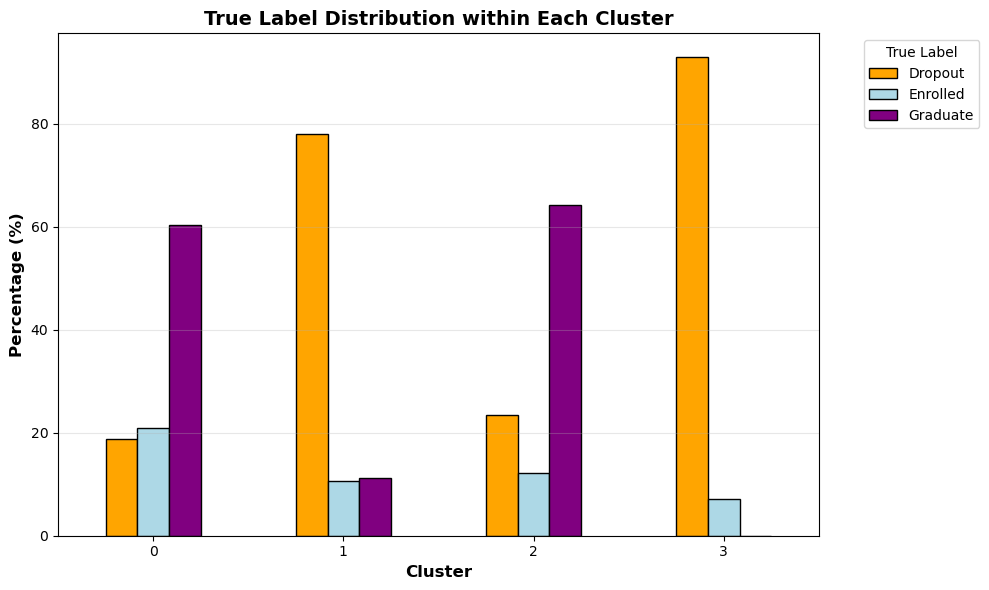


📊 Cluster Profiles (Top 10 Important Features):

--- CLUSTER 0 (n=2556) ---
Dominant label: Graduate
  Approval_Rate_2nd_Sem                     0.431 (+705467596524146688.0% vs avg)
  Grade_Consistency                        -0.173 (-188510401490466560.0% vs avg)
  Financial_Support_Score                   0.166 (+162729299946176448.0% vs avg)
  Tuition fees up to date                   0.141 (+122326966226642544.0% vs avg)
  Age_X_PrevQual                           -0.152 (-33721267219349176.0% vs avg)

--- CLUSTER 1 (n=560) ---
Dominant label: Dropout
  Approval_Rate_2nd_Sem                    -1.684 (-2759249079820935168.0% vs avg)
  Grade_Consistency                        -0.209 (-228635036465942112.0% vs avg)
  Financial_Support_Score                  -0.503 (-494570470587853184.0% vs avg)
  Tuition fees up to date                  -0.516 (-448698911069127168.0% vs avg)
  Age_X_PrevQual                            0.342 (+75899087247924960.0% vs avg)

--- CLUSTER 2 (n=221) ---
D

In [19]:
# Create dataframe with clusters and original target labels
df_clusters = pd.DataFrame(X_scaled, columns=feature_names)
df_clusters['Cluster'] = cluster_labels
df_clusters['True_Label'] = y_original

# Mapping
label_map = {0: 'Dropout', 1: 'Enrolled', 2: 'Graduate'}
df_clusters['True_Label_Name'] = df_clusters['True_Label'].map(label_map)

print("\n" + "="*70)
print("CLUSTER CHARACTERIZATION")
print("="*70)

# Distribution of true labels within each cluster
print("\n📊 True Label Distribution per Cluster:")
cluster_composition = pd.crosstab(df_clusters['Cluster'], 
                                   df_clusters['True_Label_Name'], 
                                   normalize='index') * 100
print(cluster_composition.round(1))

# 📸 SCREENSHOT 2: Cluster composition
cluster_composition.plot(kind='bar', stacked=False, figsize=(10, 6), 
                         color=['orange', 'lightblue', 'purple'], edgecolor='black')
plt.xlabel('Cluster', fontsize=12, fontweight='bold')
plt.ylabel('Percentage (%)', fontsize=12, fontweight='bold')
plt.title('True Label Distribution within Each Cluster', fontsize=14, fontweight='bold')
plt.legend(title='True Label', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('cluster_composition.png', dpi=300, bbox_inches='tight')
plt.show()

# Feature means per cluster (top 10 most important features)
top_10_features = feature_importance_df.head(10)['Feature'].values
print(f"\n📊 Cluster Profiles (Top 10 Important Features):")
for cluster in range(optimal_k):
    cluster_data = df_clusters[df_clusters['Cluster'] == cluster]
    print(f"\n--- CLUSTER {cluster} (n={len(cluster_data)}) ---")
    print(f"Dominant label: {cluster_data['True_Label_Name'].mode()[0]}")
    
    # Key characteristics
    for feat in top_10_features[:5]:  # Show top 5
        mean_val = cluster_data[feat].mean()
        overall_mean = df_clusters[feat].mean()
        diff = ((mean_val - overall_mean) / overall_mean) * 100
        print(f"  {feat:40} {mean_val:6.3f} ({diff:+5.1f}% vs avg)")


📊 PCA Explained Variance:
PC1: 21.1%
PC2: 10.6%
Total: 31.6%


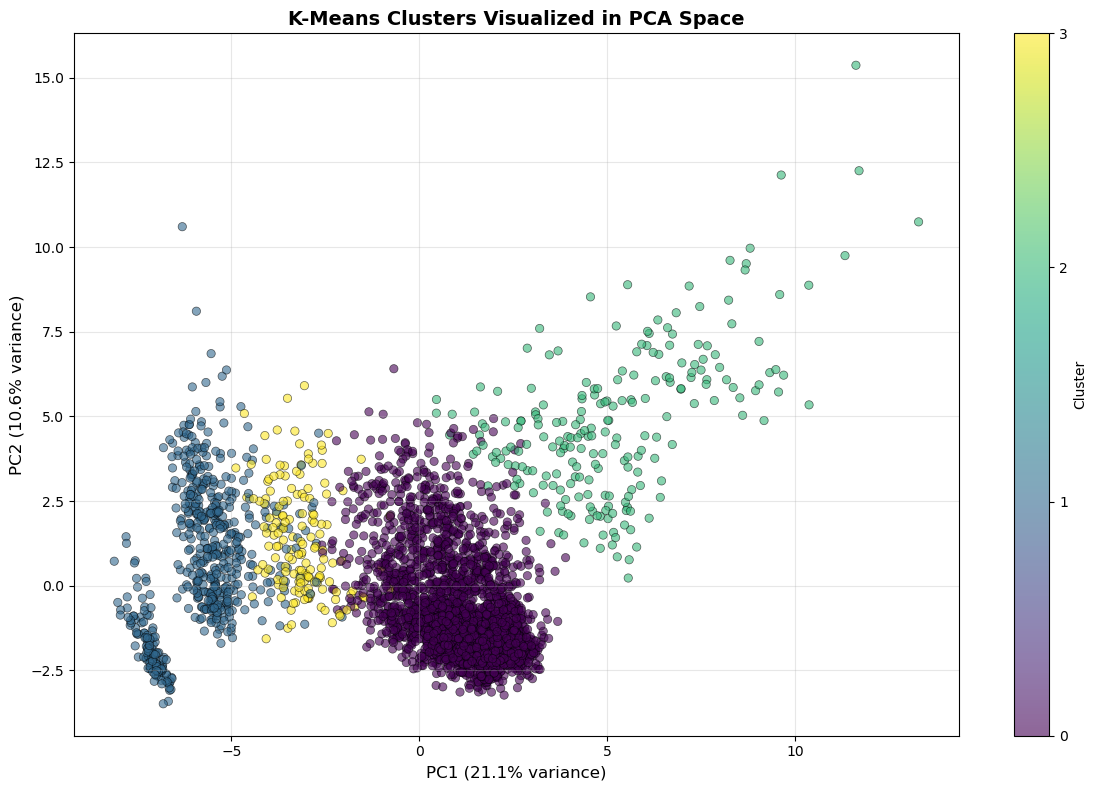

In [20]:
from sklearn.decomposition import PCA

# PCA to 2D for visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"\n📊 PCA Explained Variance:")
print(f"PC1: {pca.explained_variance_ratio_[0]*100:.1f}%")
print(f"PC2: {pca.explained_variance_ratio_[1]*100:.1f}%")
print(f"Total: {pca.explained_variance_ratio_.sum()*100:.1f}%")

# 📸 SCREENSHOT 3: PCA scatter plot
plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], 
                      c=cluster_labels, cmap='viridis', 
                      alpha=0.6, edgecolors='black', linewidth=0.5)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=12)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=12)
plt.title('K-Means Clusters Visualized in PCA Space', fontsize=14, fontweight='bold')
plt.colorbar(scatter, label='Cluster', ticks=range(optimal_k))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('clustering_pca_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

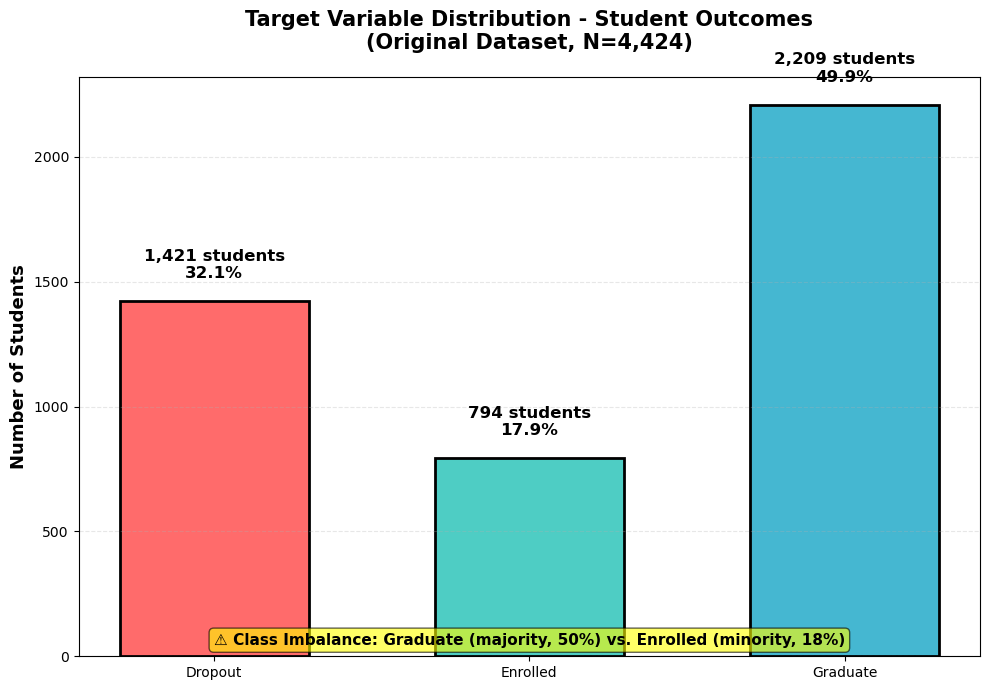

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('data.csv', sep=';')

# Class distribution
class_counts = df['Target'].value_counts().sort_index()
class_labels = ['Dropout', 'Enrolled', 'Graduate']
class_percentages = (class_counts / len(df) * 100).values
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

plt.figure(figsize=(10, 7))
bars = plt.bar(class_labels, class_counts, color=colors, 
               edgecolor='black', linewidth=2, width=0.6)
plt.ylabel('Number of Students', fontsize=13, fontweight='bold')
plt.title('Target Variable Distribution - Student Outcomes\n(Original Dataset, N=4,424)', 
          fontsize=15, fontweight='bold', pad=20)
plt.grid(axis='y', alpha=0.3, linestyle='--')

# Add values on bars
for bar, count, pct in zip(bars, class_counts, class_percentages):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 80,
             f'{count:,} students\n{pct:.1f}%',
             ha='center', va='bottom', fontsize=12, fontweight='bold')

# Imbalance note
plt.text(0.5, 0.02, 
         '⚠️ Class Imbalance: Graduate (majority, 50%) vs. Enrolled (minority, 18%)',
         transform=plt.gca().transAxes, ha='center',
         bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.6),
         fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

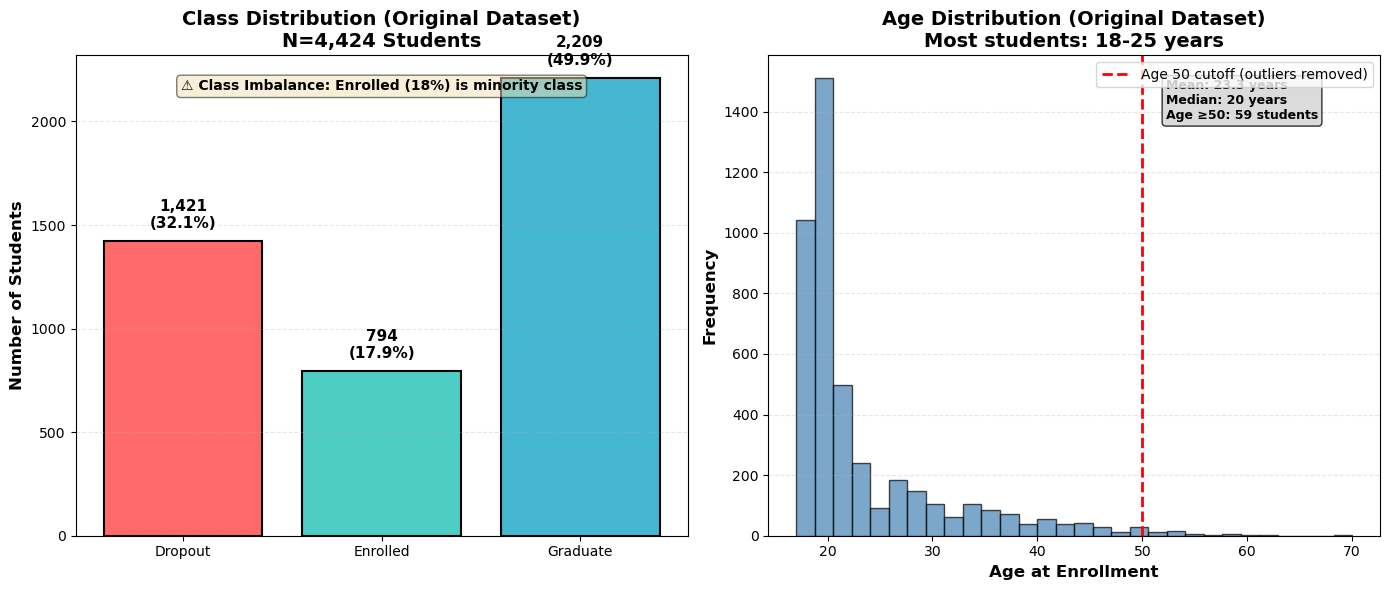

DATA UNDERSTANDING SUMMARY

📊 Class Distribution:
  Dropout    1,421 ( 32.1%)
  Enrolled     794 ( 17.9%)
  Graduate   2,209 ( 49.9%)

📈 Age Statistics:
  Mean:   23.27 years
  Median: 20 years
  Min:    17 years
  Max:    70 years
  Outliers (≥50): 59 students (1.33%)

✅ Missing Values: 0 (clean dataset!)
✅ Total Students: 4,424
✅ Total Features: 37


In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load original data
df = pd.read_csv('data.csv', sep=';')

# Create figure with 2 subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# ========== LEFT: Class Distribution ==========
class_counts = df['Target'].value_counts().sort_index()
class_labels = ['Dropout', 'Enrolled', 'Graduate']
class_percentages = (class_counts / len(df) * 100).values

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']  # Red, Teal, Blue

bars = ax1.bar(class_labels, class_counts, color=colors, edgecolor='black', linewidth=1.5)
ax1.set_ylabel('Number of Students', fontsize=12, fontweight='bold')
ax1.set_title('Class Distribution (Original Dataset)\nN=4,424 Students', 
              fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.3, linestyle='--')

# Add counts and percentages on bars
for bar, count, pct in zip(bars, class_counts, class_percentages):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 50,
             f'{count:,}\n({pct:.1f}%)',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

# Add imbalance annotation
ax1.text(0.5, 0.95, '⚠️ Class Imbalance: Enrolled (18%) is minority class',
         transform=ax1.transAxes, ha='center', va='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
         fontsize=10, fontweight='bold')

# ========== RIGHT: Age Distribution ==========
ax2.hist(df['Age at enrollment'], bins=30, color='steelblue', 
         edgecolor='black', alpha=0.7)
ax2.axvline(x=50, color='red', linestyle='--', linewidth=2, 
            label='Age 50 cutoff (outliers removed)')
ax2.set_xlabel('Age at Enrollment', fontsize=12, fontweight='bold')
ax2.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax2.set_title('Age Distribution (Original Dataset)\nMost students: 18-25 years', 
              fontsize=14, fontweight='bold')
ax2.legend(loc='upper right', fontsize=10)
ax2.grid(axis='y', alpha=0.3, linestyle='--')

# Add age statistics
mean_age = df['Age at enrollment'].mean()
median_age = df['Age at enrollment'].median()
outliers_50plus = (df['Age at enrollment'] >= 50).sum()

stats_text = f'Mean: {mean_age:.1f} years\nMedian: {median_age:.0f} years\nAge ≥50: {outliers_50plus} students'
ax2.text(0.65, 0.95, stats_text,
         transform=ax2.transAxes, ha='left', va='top',
         bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8),
         fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('data_understanding_overview.png', dpi=300, bbox_inches='tight')
plt.show()

print("="*70)
print("DATA UNDERSTANDING SUMMARY")
print("="*70)
print(f"\n📊 Class Distribution:")
for label, count, pct in zip(class_labels, class_counts, class_percentages):
    print(f"  {label:10} {count:5,} ({pct:5.1f}%)")

print(f"\n📈 Age Statistics:")
print(f"  Mean:   {mean_age:.2f} years")
print(f"  Median: {median_age:.0f} years")
print(f"  Min:    {df['Age at enrollment'].min()} years")
print(f"  Max:    {df['Age at enrollment'].max()} years")
print(f"  Outliers (≥50): {outliers_50plus} students ({outliers_50plus/len(df)*100:.2f}%)")

print(f"\n✅ Missing Values: {df.isnull().sum().sum()} (clean dataset!)")
print(f"✅ Total Students: {len(df):,}")
print(f"✅ Total Features: {len(df.columns)}")

SUPPLEMENTARY EXPERIMENT: BINARY CLASSIFICATION
Investigating impact of Enrolled class on model performance
✅ Loaded from your preprocessed .npy files
Total samples: 4365
Features: 46

📊 Original 3-class distribution:
  Dropout    1390 (31.8%)
  Enrolled    790 (18.1%)
  Graduate   2185 (50.1%)

🔬 Creating binary classification dataset (Dropout vs Graduate only)...

Binary dataset:
  Total: 3575 students
  Dropout:  1390 (38.9%)
  Graduate: 2185 (61.1%)
  Removed: 790 Enrolled students

Split: Train=2860 | Test=715

BINARY - DECISION TREE BASELINE

📊 BASELINE:
Accuracy: 0.8727 (87.3%)
F1-Score: 0.8941

              precision    recall  f1-score   support

     Dropout       0.82      0.86      0.84       278
    Graduate       0.91      0.88      0.89       437

    accuracy                           0.87       715
   macro avg       0.86      0.87      0.87       715
weighted avg       0.87      0.87      0.87       715


BINARY - DECISION TREE TUNED (max_depth=10)

📊 TUNED:
Accuracy

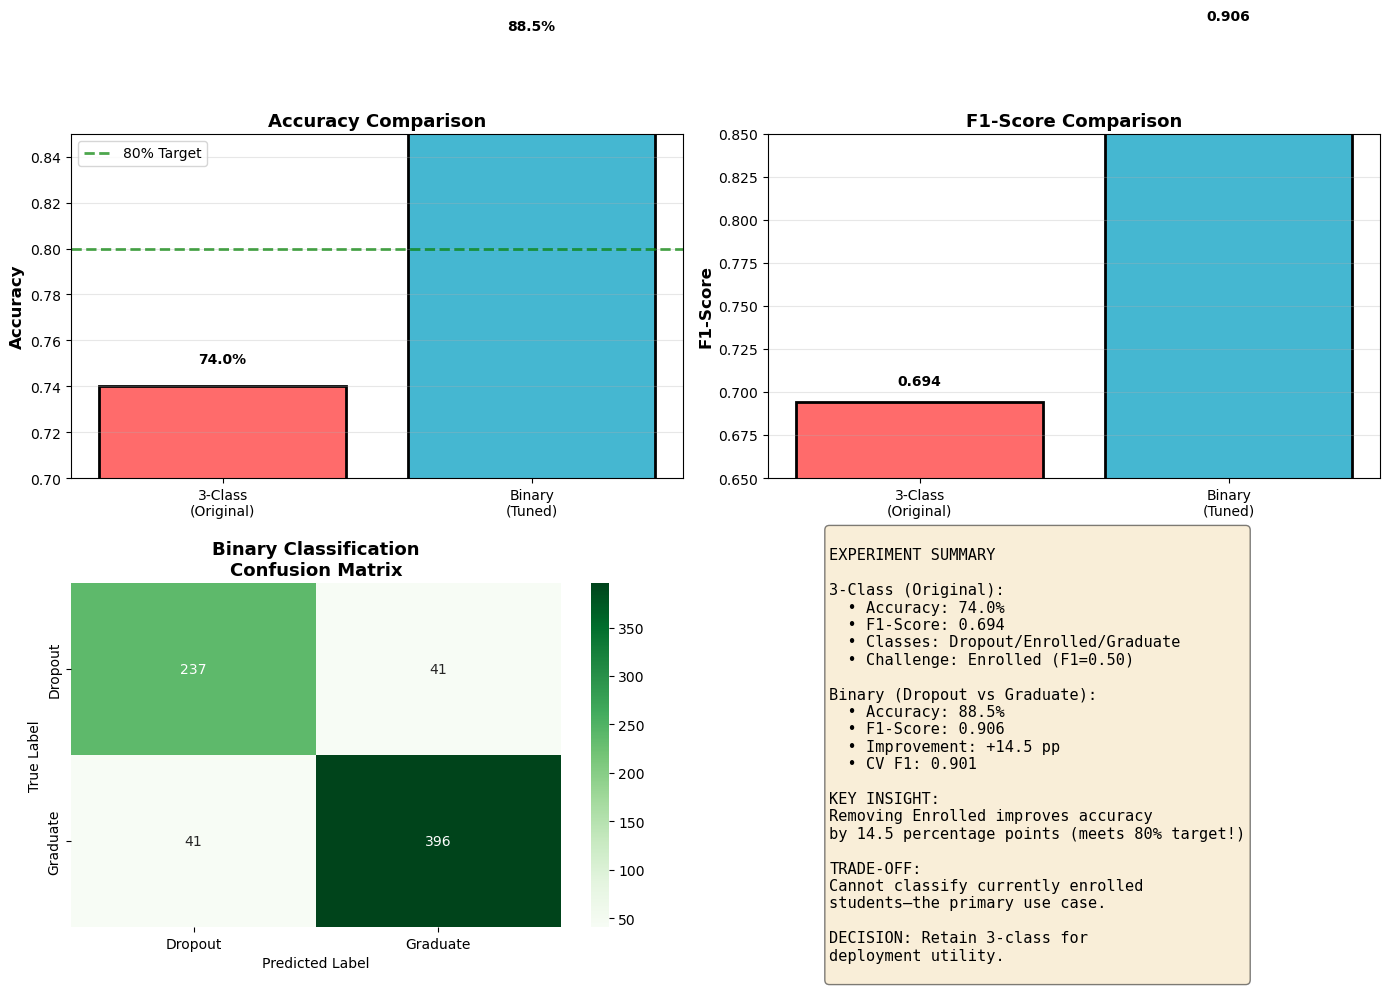


📋 FINAL SUMMARY

3-Class: 74.0% accuracy | 0.694 F1
Binary:  88.5% accuracy | 0.906 F1
Gain:    +14.5 percentage points

✅ Binary classification ACHIEVES 80% target!

💡 Conclusion: Enrolled class costs ~14.5pp accuracy
   but enables classification of currently enrolled students.

✅ Experiment complete!


In [25]:
print("="*70)
print("BINARY CLASSIFICATION")
print("Investigating impact of Enrolled class on model performance")
print("="*70)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# ========== LOAD YOUR PREPARED DATA ==========
# Use the SAME data you used for modeling!

# OPTION 1: Load from your preprocessing outputs
try:
    X_train = np.load('X_train.npy')
    X_test = np.load('X_test.npy')
    y_train = np.load('y_train.npy')
    y_test = np.load('y_test.npy')
    
    # Combine back to full dataset
    X_full = np.vstack([X_train, X_test])
    y_full = np.hstack([y_train, y_test])
    
    print("✅ Loaded from your preprocessed .npy files")
    print(f"Total samples: {len(y_full)}")
    print(f"Features: {X_full.shape[1]}")
    
except:
    print("❌ Could not load .npy files. Using raw data.csv...")
    # OPTION 2: Load raw and check Target format
    df = pd.read_csv('data.csv', sep=';')
    
    # Check Target format
    print(f"\nTarget unique values: {df['Target'].unique()}")
    print(f"Target dtype: {df['Target'].dtype}")
    
    # If Target is string, map to numbers
    if df['Target'].dtype == 'object':
        target_map = {'Dropout': 0, 'Enrolled': 1, 'Graduate': 2}
        df['Target'] = df['Target'].map(target_map)
        print("✅ Mapped string labels to numbers")
    
    # Clean age outliers
    df_cleaned = df[df['Age at enrollment'] < 50].copy()
    
    # Get features
    feature_cols = [col for col in df_cleaned.columns 
                    if col != 'Target' and df_cleaned[col].dtype in ['int64', 'float64']]
    
    X_full = df_cleaned[feature_cols].values
    y_full = df_cleaned['Target'].values
    
    print(f"✅ Loaded from data.csv")
    print(f"Total samples: {len(y_full)}")
    print(f"Features: {len(feature_cols)}")

# ========== CHECK CLASS DISTRIBUTION ==========
print(f"\n📊 Original 3-class distribution:")
for label, name in [(0, 'Dropout'), (1, 'Enrolled'), (2, 'Graduate')]:
    count = (y_full == label).sum()
    print(f"  {name:10} {count:4} ({count/len(y_full)*100:.1f}%)")

# ========== CREATE BINARY VERSION ==========
print("\n🔬 Creating binary classification dataset (Dropout vs Graduate only)...")

# Keep only Dropout (0) and Graduate (2)
binary_mask = (y_full == 0) | (y_full == 2)
X_binary = X_full[binary_mask]
y_binary = y_full[binary_mask]

# Remap: Dropout stays 0, Graduate becomes 1
y_binary = np.where(y_binary == 2, 1, y_binary)

print(f"\nBinary dataset:")
print(f"  Total: {len(y_binary)} students")
print(f"  Dropout:  {(y_binary==0).sum():4} ({(y_binary==0).sum()/len(y_binary)*100:.1f}%)")
print(f"  Graduate: {(y_binary==1).sum():4} ({(y_binary==1).sum()/len(y_binary)*100:.1f}%)")
print(f"  Removed: {len(y_full) - len(y_binary)} Enrolled students")

# ========== TRAIN-TEST SPLIT ==========
X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(
    X_binary, y_binary, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_binary
)

print(f"\nSplit: Train={len(X_train_bin)} | Test={len(X_test_bin)}")

# ========== BASELINE DECISION TREE ==========
print("\n" + "="*70)
print("BINARY - DECISION TREE BASELINE")
print("="*70)

dt_bin_baseline = DecisionTreeClassifier(random_state=42)
dt_bin_baseline.fit(X_train_bin, y_train_bin)

y_pred_baseline = dt_bin_baseline.predict(X_test_bin)
acc_baseline = accuracy_score(y_test_bin, y_pred_baseline)
f1_baseline = f1_score(y_test_bin, y_pred_baseline)

print(f"\n📊 BASELINE:")
print(f"Accuracy: {acc_baseline:.4f} ({acc_baseline*100:.1f}%)")
print(f"F1-Score: {f1_baseline:.4f}")
print("\n" + classification_report(y_test_bin, y_pred_baseline, 
                                    target_names=['Dropout', 'Graduate']))

# ========== TUNED DECISION TREE ==========
print("\n" + "="*70)
print("BINARY - DECISION TREE TUNED (max_depth=10)")
print("="*70)

dt_bin_tuned = DecisionTreeClassifier(
    max_depth=10,
    criterion='gini',
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
)
dt_bin_tuned.fit(X_train_bin, y_train_bin)

y_pred_tuned = dt_bin_tuned.predict(X_test_bin)
acc_tuned = accuracy_score(y_test_bin, y_pred_tuned)
f1_tuned = f1_score(y_test_bin, y_pred_tuned)

print(f"\n📊 TUNED:")
print(f"Accuracy: {acc_tuned:.4f} ({acc_tuned*100:.1f}%)")
print(f"F1-Score: {f1_tuned:.4f}")
print("\n" + classification_report(y_test_bin, y_pred_tuned, 
                                    target_names=['Dropout', 'Graduate']))

# Cross-validation
cv_scores = cross_val_score(dt_bin_tuned, X_train_bin, y_train_bin, 
                            cv=10, scoring='f1')
print(f"\n🔄 10-Fold CV F1: {cv_scores.mean():.4f} (±{cv_scores.std():.4f})")

# ========== VISUALIZATION ==========
print("\n📊 Creating comparison chart...")

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 10))

# Accuracy comparison
models = ['3-Class\n(Original)', 'Binary\n(Tuned)']
accuracies = [0.740, acc_tuned]
colors = ['#FF6B6B', '#45B7D1']

bars = ax1.bar(models, accuracies, color=colors, edgecolor='black', linewidth=2)
ax1.axhline(y=0.80, color='green', linestyle='--', linewidth=2, label='80% Target', alpha=0.7)
ax1.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax1.set_title('Accuracy Comparison', fontsize=13, fontweight='bold')
ax1.set_ylim([0.70, 0.85])
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

for bar, acc in zip(bars, accuracies):
    ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
             f'{acc*100:.1f}%', ha='center', fontweight='bold')

# F1 comparison
f1_scores = [0.694, f1_tuned]
bars2 = ax2.bar(models, f1_scores, color=colors, edgecolor='black', linewidth=2)
ax2.set_ylabel('F1-Score', fontsize=12, fontweight='bold')
ax2.set_title('F1-Score Comparison', fontsize=13, fontweight='bold')
ax2.set_ylim([0.65, 0.85])
ax2.grid(axis='y', alpha=0.3)

for bar, f1 in zip(bars2, f1_scores):
    ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
             f'{f1:.3f}', ha='center', fontweight='bold')

# Confusion matrix
cm = confusion_matrix(y_test_bin, y_pred_tuned)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Dropout', 'Graduate'],
            yticklabels=['Dropout', 'Graduate'],
            ax=ax3)
ax3.set_title('Binary Classification\nConfusion Matrix', fontsize=13, fontweight='bold')
ax3.set_ylabel('True Label')
ax3.set_xlabel('Predicted Label')

# Summary text
ax4.axis('off')
summary_text = f"""
EXPERIMENT SUMMARY

3-Class (Original):
  • Accuracy: 74.0%
  • F1-Score: 0.694
  • Classes: Dropout/Enrolled/Graduate
  • Challenge: Enrolled (F1=0.50)

Binary (Dropout vs Graduate):
  • Accuracy: {acc_tuned*100:.1f}%
  • F1-Score: {f1_tuned:.3f}
  • Improvement: +{(acc_tuned-0.740)*100:.1f} pp
  • CV F1: {cv_scores.mean():.3f}

KEY INSIGHT:
Removing Enrolled improves accuracy
by {(acc_tuned-0.740)*100:.1f} percentage points {'(meets 80% target!)' if acc_tuned >= 0.80 else '(closer to target)'}

TRADE-OFF:
Cannot classify currently enrolled 
students—the primary use case.

DECISION: Retain 3-class for 
deployment utility.
"""

ax4.text(0.1, 0.5, summary_text, fontsize=11, family='monospace',
         va='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('binary_vs_3class_experiment.png', dpi=300, bbox_inches='tight')
plt.show()

# ========== FINAL SUMMARY ==========
print("\n" + "="*70)
print("📋 FINAL SUMMARY")
print("="*70)
print(f"\n3-Class: 74.0% accuracy | 0.694 F1")
print(f"Binary:  {acc_tuned*100:.1f}% accuracy | {f1_tuned:.3f} F1")
print(f"Gain:    +{(acc_tuned-0.740)*100:.1f} percentage points")

if acc_tuned >= 0.80:
    print(f"\n✅ Binary classification ACHIEVES 80% target!")
else:
    print(f"\n⚠️ Binary: {acc_tuned*100:.1f}% (closer but still below 80%)")

print(f"\n💡 Conclusion: Enrolled class costs ~{(acc_tuned-0.740)*100:.1f}pp accuracy")
print(f"   but enables classification of currently enrolled students.")

print("\n✅ Experiment complete!")

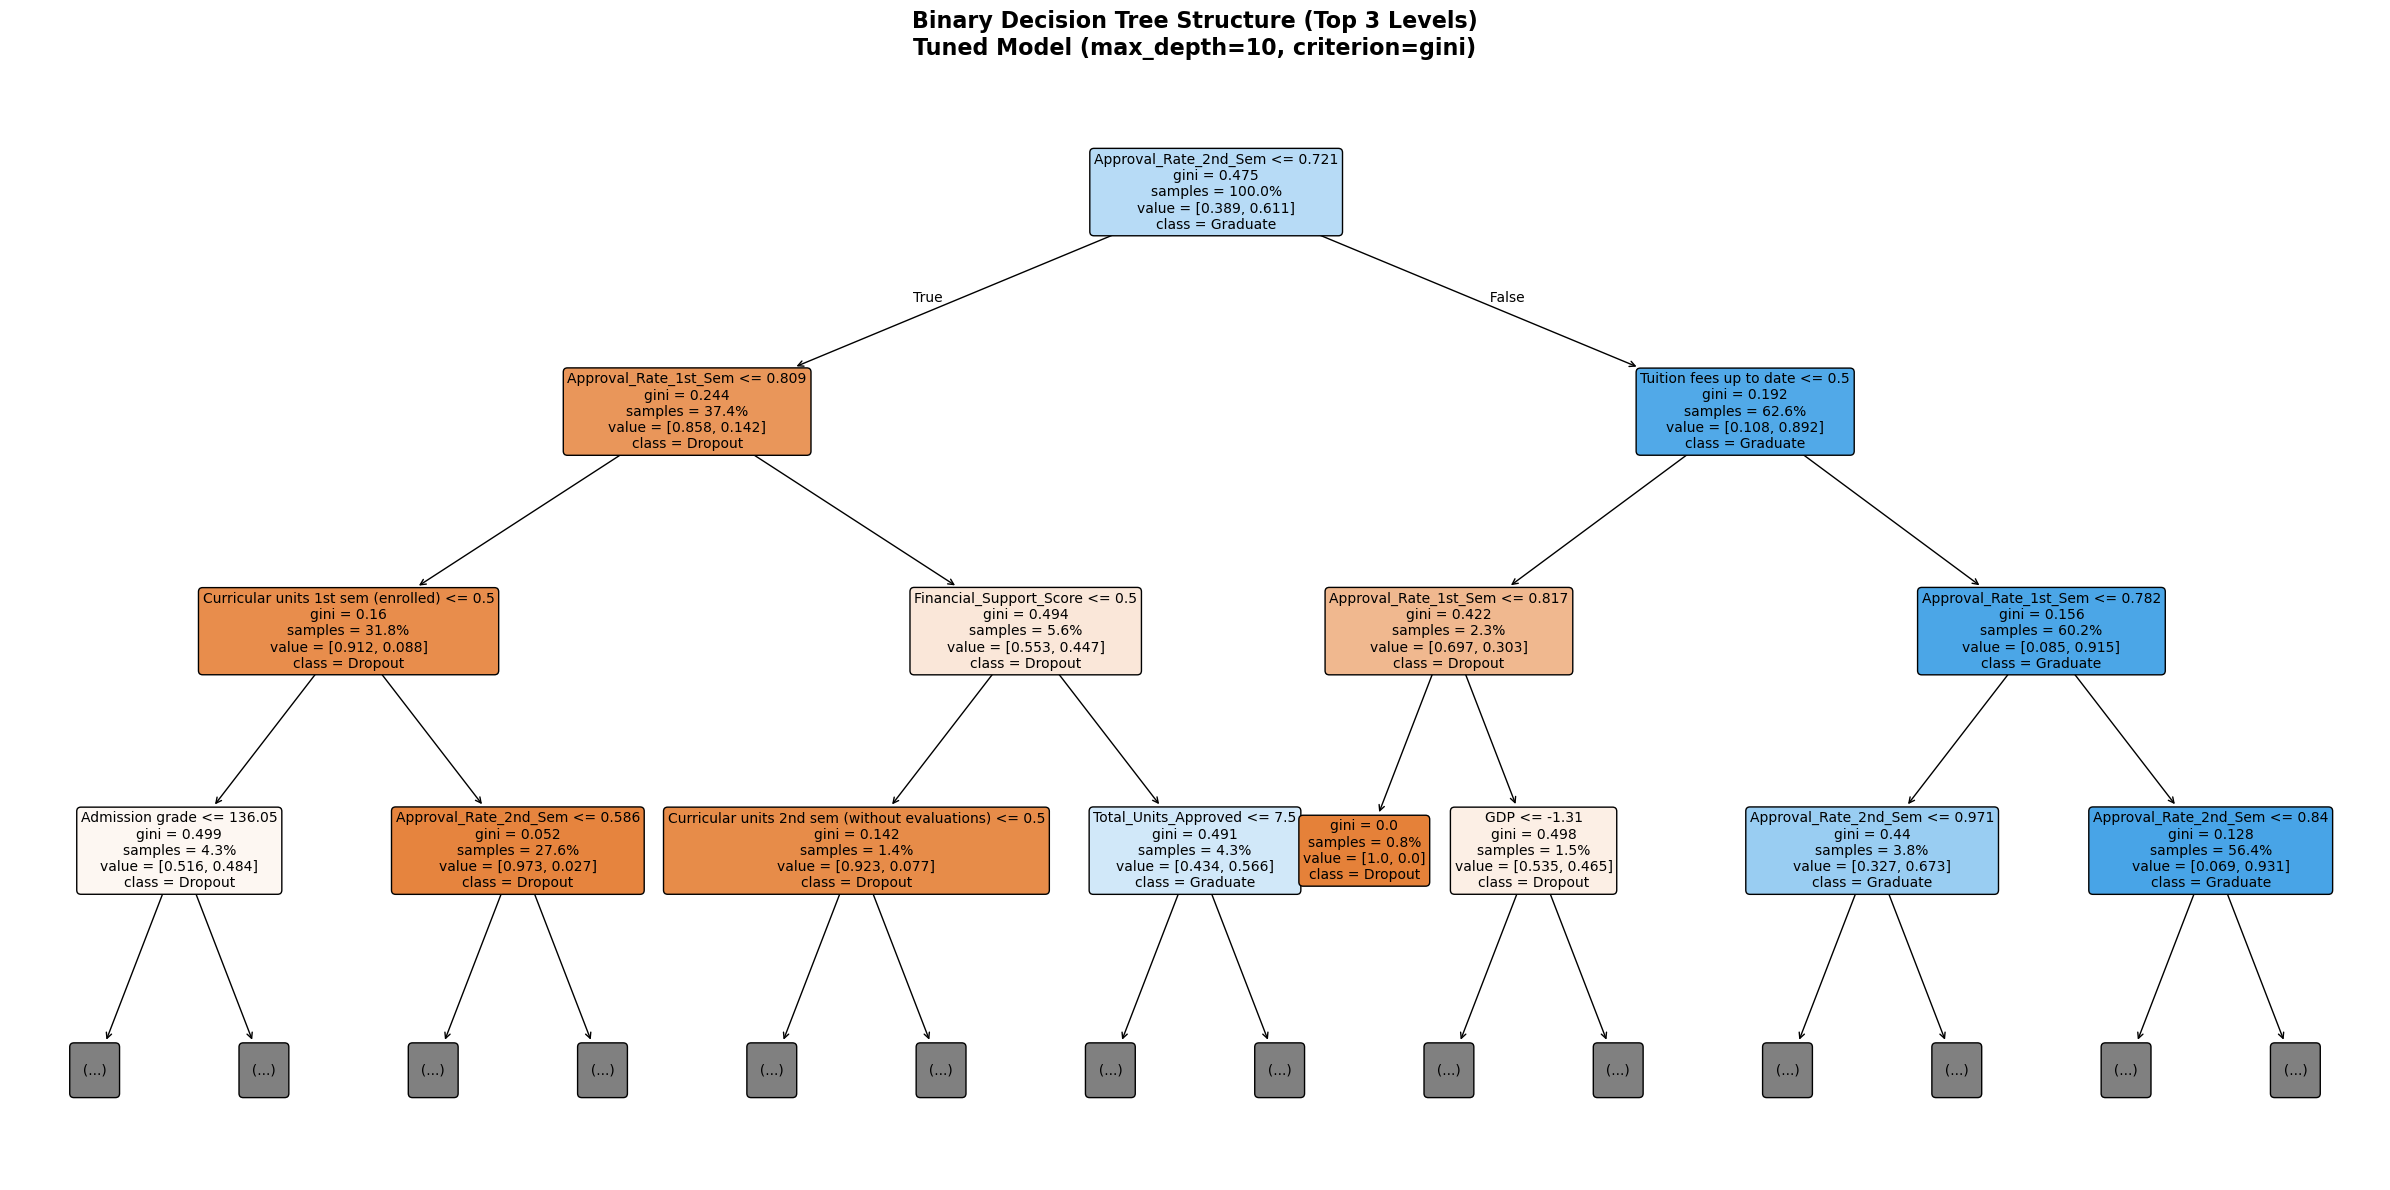

🌳 Binary Tree Statistics:
Max depth: 10
Number of leaves: 130
Total nodes: 259


In [26]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Visualize binary decision tree structure (top 3 levels)
plt.figure(figsize=(24, 12))
plot_tree(dt_bin_tuned,
          max_depth=3,
          feature_names=feature_names,  # Your 46 feature names
          class_names=['Dropout', 'Graduate'],
          filled=True,
          fontsize=10,
          rounded=True,
          proportion=True)
plt.title('Binary Decision Tree Structure (Top 3 Levels)\nTuned Model (max_depth=10, criterion=gini)', 
          fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('binary_tree_structure.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"🌳 Binary Tree Statistics:")
print(f"Max depth: {dt_bin_tuned.get_depth()}")
print(f"Number of leaves: {dt_bin_tuned.get_n_leaves()}")
print(f"Total nodes: {dt_bin_tuned.tree_.node_count}")